In [42]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import os, glob
import h5py

import sys
sys.path.append('../../')
import analysis_utils as utils
utils.load_plotting_setting()

import calc_gas_collision_spectrum as calc_gas

In [43]:
import importlib
importlib.reload(utils)
importlib.reload(calc_gas)

<module 'calc_gas_collision_spectrum' from '/Users/yuhan/work/nanospheres/gas_collisions/analysis_notebooks/sphere_20260215_final_analysis/../../calc_gas_collision_spectrum.py'>

In [44]:
search_window_length = 2**8
time_per_search = 200e-9 * search_window_length  # s

# ── Config ────────────────────────────────────────────────────────────────
# To plot a different sphere/run, change recon_file and gas_types below.
recon_file = r'/Users/yuhan/work/nanospheres/gas_collisions/data_processed/gas_recon/sphere_20260215_gas_recon_all.h5py'
gas_types = ['xenon', 'krypton', 'sf6', 'background']

# Stage suffixes added by recon_histograms.py (used to identify base dataset names)
_stage_suffixes = (
    '_nocal', '_cal',
    '_nocuts', '_nocuts_nocal', '_nocuts_cal',
    '_hom_bal', '_hom_bal_nocal', '_hom_bal_cal',
    '_noise', '_noise_nocal', '_noise_cal',
    '_drive', '_drive_nocal', '_drive_cal',
    '_chi2', '_chi2_nocal', '_chi2_cal',
)
# ─────────────────────────────────────────────────────────────────────────

with h5py.File(recon_file, 'r') as f:
    bins = np.arange(0, 2000, 25)
    bc   = f['recon_histograms']['bc'][:]

    # Load all histograms sorted by pressure (high → low).
    # If both 'name' and 'name_1' exist, keep only 'name_1'.
    # Each entry: (hh, hh_nocal, hh_cal, pressure_mbar)
    hhs = {}
    for gas in gas_types:
        grp = f['recon_histograms'][gas]
        # Base dataset names: exclude all stage suffixes
        datasets = [k for k in grp
                    if not any(k.endswith(s) for s in _stage_suffixes)]
        superseded = {d[:-2] for d in datasets if d.endswith('_1')}
        datasets = [d for d in datasets if d not in superseded]
        datasets.sort(key=lambda d: grp[d].attrs['pressure_mbar'], reverse=True)
        hhs[gas] = [(grp[d][:], grp[d + '_nocal'][:], grp[d + '_cal'][:],
                     grp[d].attrs['pressure_mbar']) for d in datasets]

In [45]:
hhs_bg = np.asarray([hhs['background'][i][1] for i in range(4)])
hhs_bg_wcal = np.asarray([hhs['background'][i][0] for i in range(4)])

hh_bg_avg, hh_bg_max, hh_bg_min = np.mean(hhs_bg, axis=0), np.max(hhs_bg, axis=0), np.min(hhs_bg, axis=0)
hh_bg_wcal_avg, hh_bg_wcal_max, hh_bg_wcal_min = np.mean(hhs_bg_wcal, axis=0), np.max(hhs_bg_wcal, axis=0), np.min(hhs_bg_wcal, axis=0)

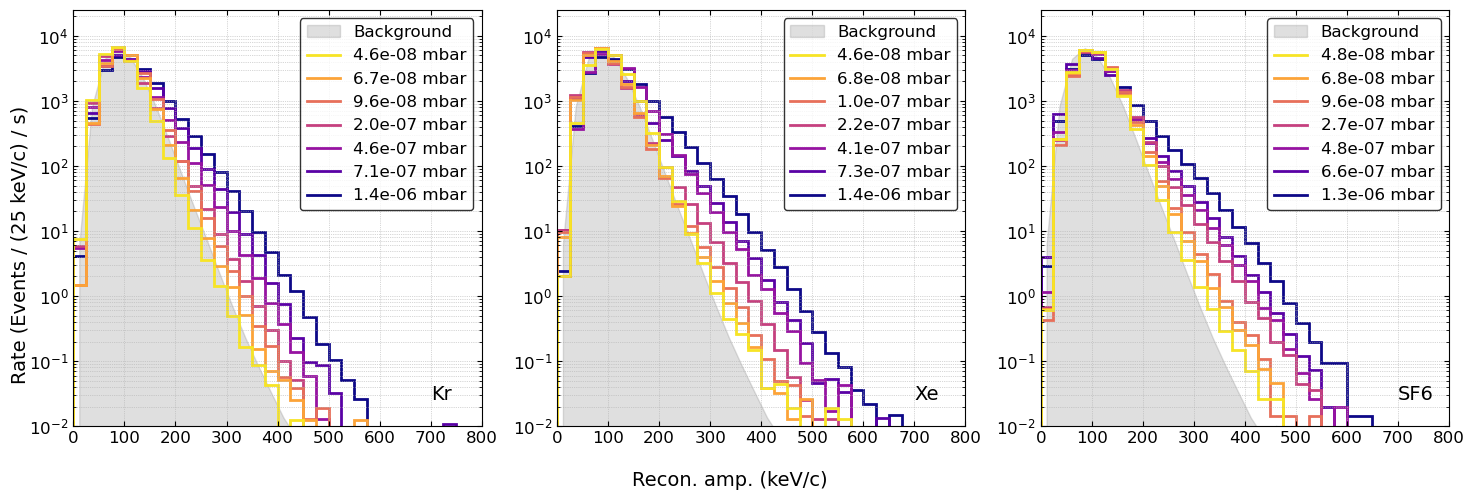

In [46]:
colors = plt.colormaps['plasma'](np.linspace(0, 0.95, 7))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, gas, label in zip(axes, ['krypton', 'xenon', 'sf6'], ['Kr', 'Xe', 'SF6']):
    ax.fill_between(bc, 0, hh_bg_avg/(time_per_search*np.sum(hh_bg_avg)), color='gray', alpha=0.25, label='Background')

    for c, (hh, hh_nocal, hh_cal, p_mbar) in zip(colors, hhs[gas]):
        norm = time_per_search * np.sum(hh_nocal)
        ax.stairs(hh_nocal / norm, edges=bins, color=c, linewidth=2, linestyle='-', label=f'{p_mbar:.1e} mbar')

    ax.text(700, 2.5e-2, label, fontsize=14)
    ax.set_yscale('log')
    ax.set_xlim(0, 800)
    ax.set_ylim(1e-2, 2.5e4)
    ax.grid(which='both', ls=':', linewidth=0.5)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:1] + handles[1:][::-1], labels[:1] + labels[1:][::-1], edgecolor='k')

fig.supxlabel('Recon. amp. (keV/c)', fontsize=14)
fig.supylabel('Rate (Events / (25 keV/c) / s)', fontsize=14)
fig.tight_layout()

## Signal-only likelihood fit (> 300 keV/c, no background)

In [74]:
import gas_likelihood_fit as glf
importlib.reload(glf)

# ── Fit configuration ─────────────────────────────────────────────────────
fit_band_sigonly = (300, 800)  # keV/c
frac_uncertainty = 0.10
k_negbin = 1.0 / frac_uncertainty**2
amp_scale_sigma = 0.10  # 10% Gaussian constraint on amplitude scale nuisance parameter

# Theory parameters (same as gen_signal_model_mc.py)
alpha = 0.9
T_gas = 293
T_sensor = 293.05
sphere_radius = 50e-9

gas_masses = {'xenon': 131.293, 'krypton': 83.798, 'sf6': 146.056}
qq_kev = np.linspace(0.5, 2000, 2000)

# Compute theory spectrum at 1e-8 mbar reference for each gas
drdqz_by_gas = {}
for gas, mg in gas_masses.items():
    drdq = calc_gas.dgamma_dp_tot_noneq(
        qq_kev, mg, p_mbar=1e-8, alpha=alpha,
        T_gas=T_gas, T_sensor=T_sensor, sphere_radius=sphere_radius)
    _, drdqz = calc_gas.get_drdqz(qq_kev, drdq)
    drdqz_by_gas[gas] = np.interp(bc, qq_kev, drdqz)
    print(f'{gas}: rate @ 1e-8 mbar = {np.trapz(drdqz, qq_kev):.3f} Hz')

print(f'\nfit_band = {fit_band_sigonly}, k = {k_negbin:.1f} (f = {frac_uncertainty:.0%})')
print(f'amp_scale_sigma = {amp_scale_sigma}')

xenon: rate @ 1e-8 mbar = 420.178 Hz
krypton: rate @ 1e-8 mbar = 525.359 Hz
sf6: rate @ 1e-8 mbar = 398.468 Hz

fit_band = (300, 800), k = 100.0 (f = 10%)
amp_scale_sigma = 0.1


In [75]:
# Signal-only fit using hhs[gas] _nocal histograms (all cuts + double-count rejection, cal excluded)
results_sigonly = {}

for gas in gas_masses:
    drdqz_bc = drdqz_by_gas[gas]
    for i, (hh, hh_nocal, hh_cal, p_mbar) in enumerate(hhs[gas]):
        h = hh_nocal

        nll, params = glf.minimize_nll_negbin(
            drdqz_bc, bc, h,
            glf.eff_coefs, glf.eff_chi2, fit_band_sigonly,
            k_negbin, glf.nll_offset, signal_only=True,
            amp_scale_sigma=amp_scale_sigma
        )
        sigma_fit, log10_p_fit, amp_scale_fit = params

        # GOF: apply amp_scale to theory before building model counts
        p_scale = 10**(log10_p_fit - (-8))
        if amp_scale_fit != 1.0:
            drdqz_scaled = np.interp(bc / amp_scale_fit, bc, drdqz_bc) / amp_scale_fit
        else:
            drdqz_scaled = drdqz_bc
        _, drdqzn = calc_gas.smear_drdqz_gauss(bc, drdqz_scaled, sigma_fit)
        mu_fit, idx_fit = glf.build_model_counts(
            sigma_fit, drdqzn * p_scale, bc, h, glf.eff_coefs, glf.eff_chi2, fit_band_sigonly, signal_only=True)
        gof = glf.calc_gof(mu_fit, h[idx_fit], nparams=3, k=k_negbin)

        results_sigonly[(gas, i)] = {
            'sigma': sigma_fit, 'log10_p': log10_p_fit, 'amp_scale': amp_scale_fit,
            'nll': nll, 'pressure_mbar': p_mbar, 'hist': h,
            'gof_chi2': gof[0], 'gof_ndof': gof[1],
            'gof_chi2_ndf': gof[2], 'gof_pval': gof[3],
        }

    # Also fit averaged background histogram with this gas's theory
    h_bg = hh_bg_avg.copy()
    nll_bg, params_bg = glf.minimize_nll_negbin(
        drdqz_bc, bc, h_bg,
        glf.eff_coefs, glf.eff_chi2, fit_band_sigonly,
        k_negbin, glf.nll_offset, signal_only=True,
        amp_scale_sigma=amp_scale_sigma
    )
    sigma_bg, log10_p_bg, amp_scale_bg = params_bg

    p_scale_bg = 10**(log10_p_bg - (-8))
    if amp_scale_bg != 1.0:
        drdqz_scaled_bg = np.interp(bc / amp_scale_bg, bc, drdqz_bc) / amp_scale_bg
    else:
        drdqz_scaled_bg = drdqz_bc
    _, drdqzn_bg = calc_gas.smear_drdqz_gauss(bc, drdqz_scaled_bg, sigma_bg)
    mu_bg, idx_bg = glf.build_model_counts(
        sigma_bg, drdqzn_bg * p_scale_bg, bc, h_bg, glf.eff_coefs, glf.eff_chi2, fit_band_sigonly, signal_only=True)
    gof_bg = glf.calc_gof(mu_bg, h_bg[idx_bg], nparams=3, k=k_negbin)

    results_sigonly[('bg_as_' + gas, 0)] = {
        'sigma': sigma_bg, 'log10_p': log10_p_bg, 'amp_scale': amp_scale_bg,
        'nll': nll_bg, 'pressure_mbar': 0.0, 'hist': h_bg,
        'gof_chi2': gof_bg[0], 'gof_ndof': gof_bg[1],
        'gof_chi2_ndf': gof_bg[2], 'gof_pval': gof_bg[3],
    }

    print(f'{gas}: fitted {len(hhs[gas])} datasets + background')
    print(f'  bg -> sigma={sigma_bg:.1f} keV/c, p_fit={10**log10_p_bg:.2e} mbar, '
          f's={amp_scale_bg:.3f}, chi2/ndf={gof_bg[2]:.2f} (p={gof_bg[3]:.3e})')

print(f'\nTotal fits: {len(results_sigonly)}')

xenon: fitted 7 datasets + background
  bg -> sigma=25.0 keV/c, p_fit=7.49e-09 mbar, s=1.080, chi2/ndf=1.02 (p=3.811e-01)
krypton: fitted 7 datasets + background
  bg -> sigma=74.7 keV/c, p_fit=2.86e-09 mbar, s=1.030, chi2/ndf=2.49 (p=5.812e-02)
sf6: fitted 7 datasets + background
  bg -> sigma=25.0 keV/c, p_fit=7.56e-09 mbar, s=1.025, chi2/ndf=1.25 (p=2.914e-01)

Total fits: 24


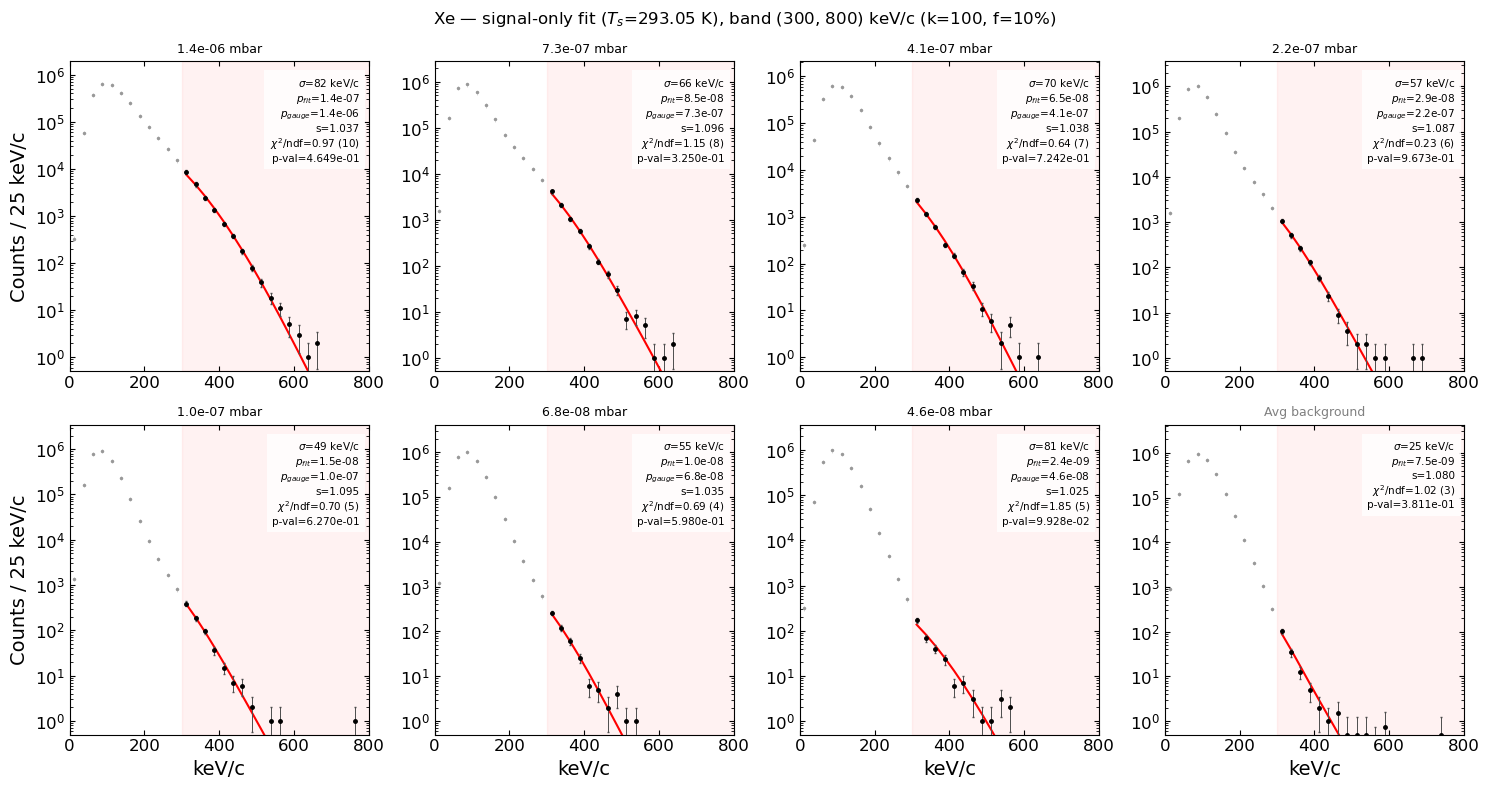

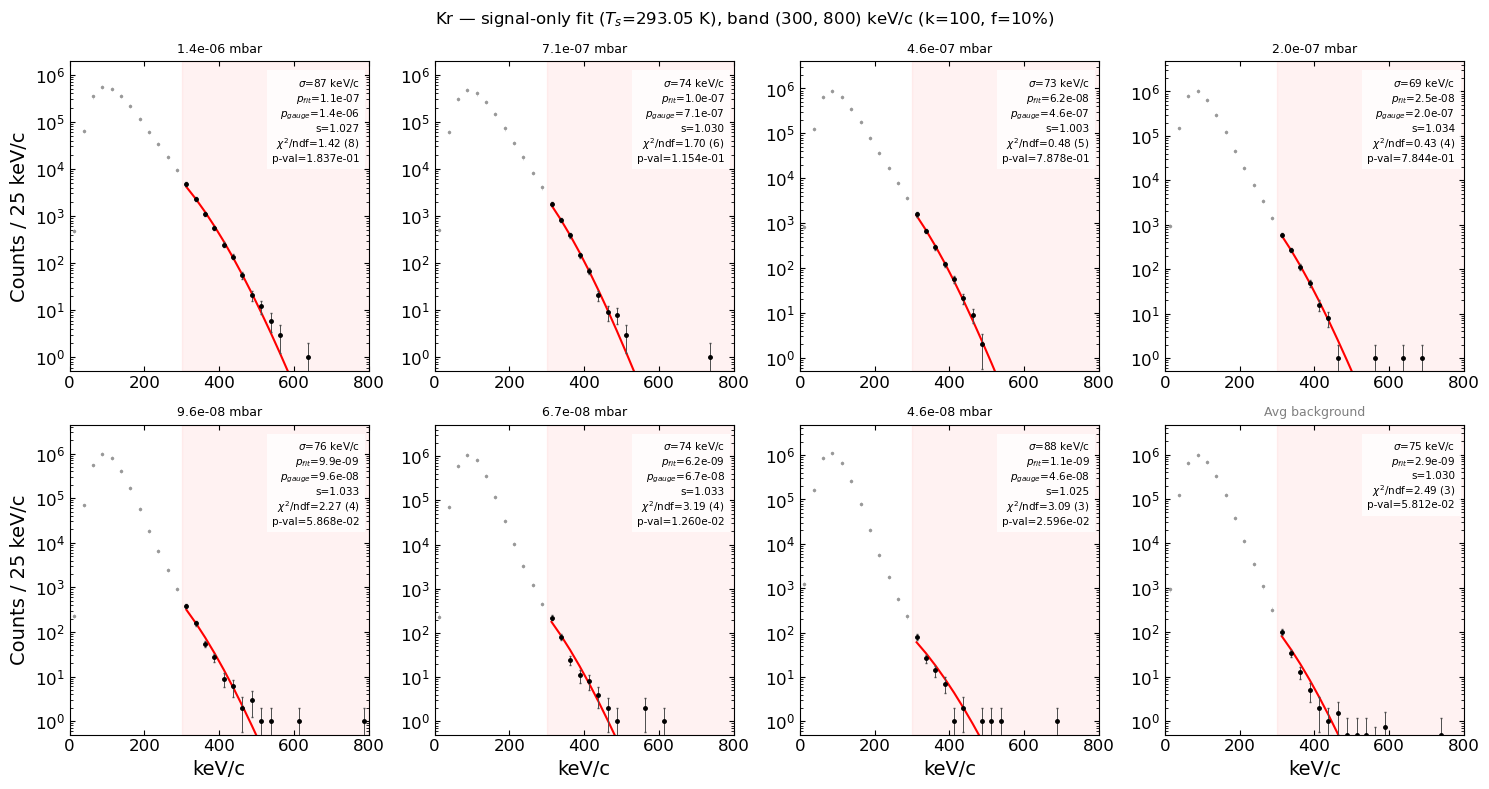

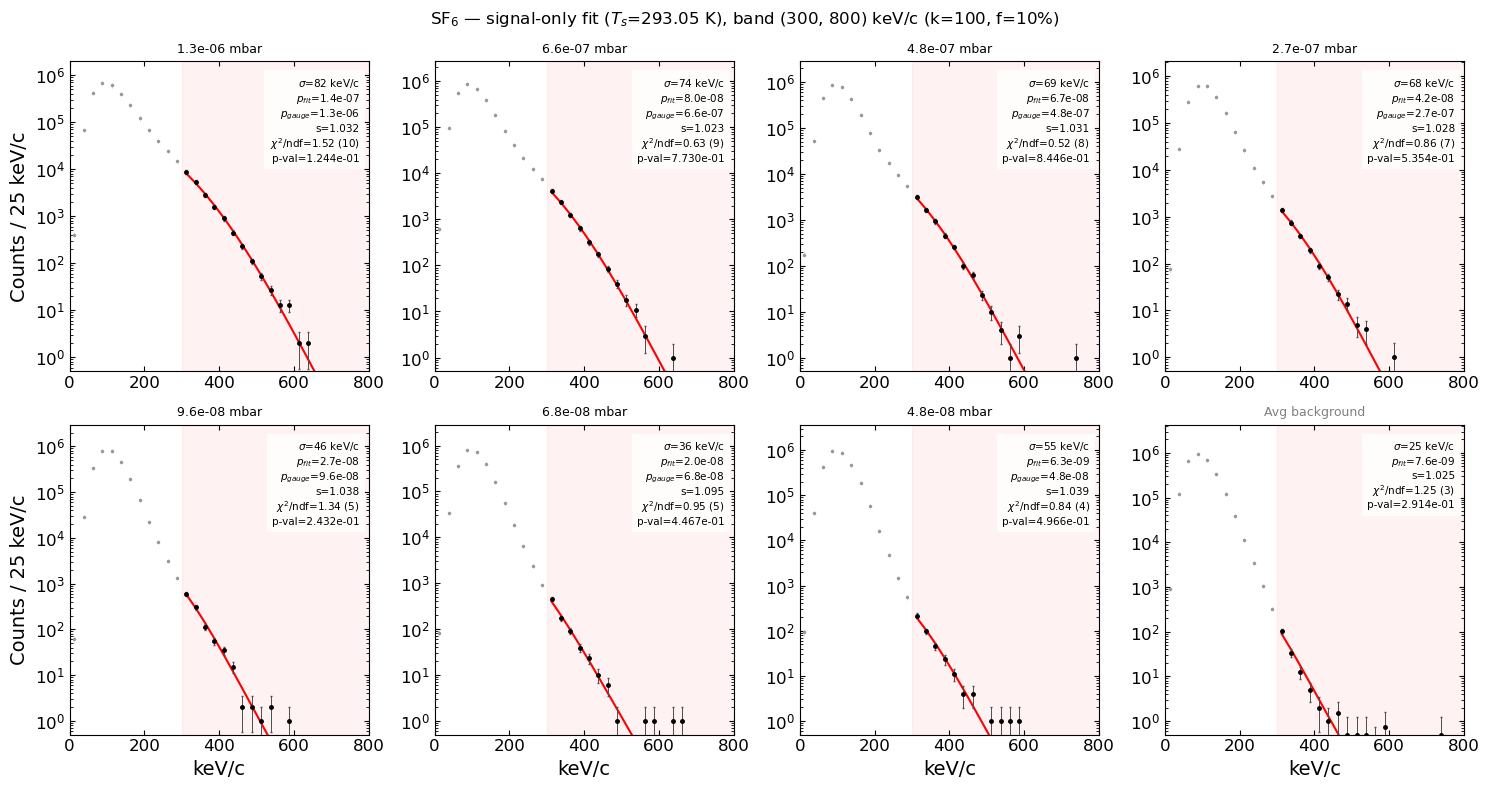

In [76]:
# Plot: 2×4 grid per gas type (last panel = averaged background fitted with that gas's theory)
gas_labels = {'xenon': 'Xe', 'krypton': 'Kr', 'sf6': 'SF$_6$'}
dq = bc[1] - bc[0]

for gas in gas_masses:
    entries = hhs[gas]
    n = len(entries)
    ncols = 4
    nrows = 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 8))
    axes_flat = axes.flatten()

    drdqz_bc = drdqz_by_gas[gas]

    # n_total = gas datasets + 1 background panel
    n_total = n + 1

    for j in range(ncols * nrows):
        ax = axes_flat[j]
        if j >= n_total:
            ax.set_visible(False)
            continue

        is_bg = (j == n)
        if is_bg:
            r = results_sigonly[('bg_as_' + gas, 0)]
        else:
            r = results_sigonly[(gas, j)]

        h = r['hist'].astype(float)
        sigma = r['sigma']
        log10_p_fit = r['log10_p']
        amp_s = r['amp_scale']
        p_mbar = r['pressure_mbar']

        idx_fit = (bc > fit_band_sigonly[0]) & (bc < fit_band_sigonly[1])
        bc_fit = bc[idx_fit]

        err_full = np.sqrt(h + h**2 / k_negbin)
        err_fit = np.sqrt(h[idx_fit] + h[idx_fit]**2 / k_negbin)

        ax.errorbar(bc, h, yerr=err_full, fmt='none', ecolor='0.8', elinewidth=0.5, capsize=0)
        ax.plot(bc, h, 'o', ms=1.5, color='0.6')
        ax.errorbar(bc_fit, h[idx_fit], yerr=err_fit, fmt='o', ms=2.5, color='k',
                    ecolor='0.3', elinewidth=0.7, capsize=1, zorder=5)

        # Signal-only model with amp_scale
        if amp_s != 1.0:
            drdqz_s = np.interp(bc / amp_s, bc, drdqz_bc) / amp_s
        else:
            drdqz_s = drdqz_bc
        _, drdqzn = calc_gas.smear_drdqz_gauss(bc, drdqz_s, sigma)
        p_scale = 10**(log10_p_fit - (-8))
        h_norm = np.sum(h) * glf.length_search_window * dq
        eff = glf.func_eff(bc, *glf.eff_coefs)
        h_gas = glf.eff_chi2 * eff * drdqzn * p_scale * h_norm

        ax.plot(bc_fit, h_gas[idx_fit], 'r-', lw=1.5, label='Signal')
        ax.axvspan(fit_band_sigonly[0], fit_band_sigonly[1], alpha=0.05, color='red')
        ax.set_yscale('log')
        ax.set_xlim(0, 800)
        ax.set_ylim(bottom=0.5)

        p_fit = 10**log10_p_fit
        ax.text(0.97, 0.95,
                f'$\\sigma$={sigma:.0f} keV/c\n'
                f'$p_{{fit}}$={p_fit:.1e}\n'
                + (f'$p_{{gauge}}$={p_mbar:.1e}\n' if not is_bg else '')
                + f's={amp_s:.3f}\n'
                f'$\\chi^2$/ndf={r["gof_chi2_ndf"]:.2f} ({r["gof_ndof"]})\n'
                f'p-val={r["gof_pval"]:.3e}',
                transform=ax.transAxes, va='top', ha='right', fontsize=7.5,
                bbox=dict(fc='white', alpha=0.8, ec='none'))

        if is_bg:
            ax.set_title('Avg background', fontsize=9, color='gray')
        else:
            ax.set_title(f'{p_mbar:.1e} mbar', fontsize=9)
        if j % ncols == 0:
            ax.set_ylabel('Counts / 25 keV/c')
        if j >= ncols:
            ax.set_xlabel('keV/c')

    fig.suptitle(f'{gas_labels[gas]} — signal-only fit ($T_s$={T_sensor} K), '
                 f'band {fit_band_sigonly} keV/c (k={k_negbin:.0f}, f={frac_uncertainty:.0%})',
                 fontsize=12)
    fig.tight_layout()
    plt.show()

Background fit results (avg background fitted with each gas theory):
  xenon   : p_fit=7.49e-09 mbar, sigma=25.0 keV/c, s=1.080, chi2/ndf=1.02 (p=3.811e-01)
  krypton : p_fit=2.86e-09 mbar, sigma=74.7 keV/c, s=1.030, chi2/ndf=2.49 (p=5.812e-02)
  sf6     : p_fit=7.56e-09 mbar, sigma=25.0 keV/c, s=1.025, chi2/ndf=1.25 (p=2.914e-01)


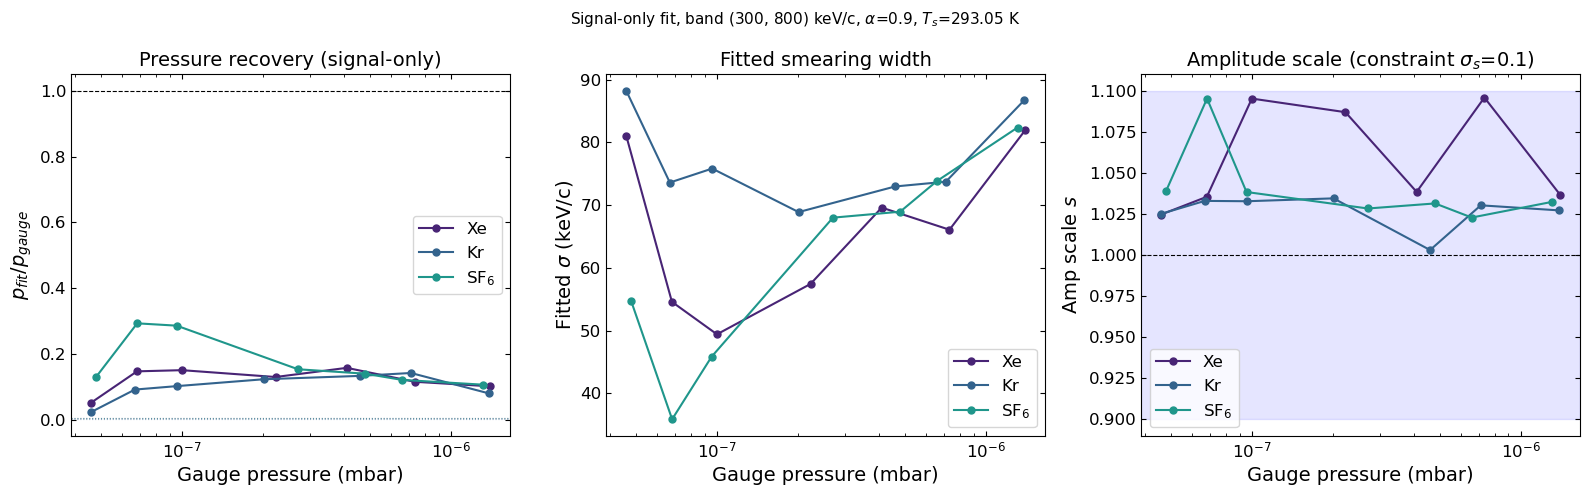

In [78]:
# Summary: p_fit / p_gauge, fitted sigma, and amp_scale for each gas
# Background fit results shown as horizontal bands
gas_labels = {'xenon': 'Xe', 'krypton': 'Kr', 'sf6': 'SF$_6$'}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for gas in gas_masses:
    n_datasets = len(hhs[gas])
    p_gauge = np.array([results_sigonly[(gas, i)]['pressure_mbar'] for i in range(n_datasets)])
    p_fit = np.array([10**results_sigonly[(gas, i)]['log10_p'] for i in range(n_datasets)])
    sigmas = np.array([results_sigonly[(gas, i)]['sigma'] for i in range(n_datasets)])
    amp_scales = np.array([results_sigonly[(gas, i)]['amp_scale'] for i in range(n_datasets)])

    # Background fit result for this gas
    r_bg = results_sigonly[('bg_as_' + gas, 0)]
    p_bg_fit = 10**r_bg['log10_p']
    sigma_bg = r_bg['sigma']
    amp_scale_bg = r_bg['amp_scale']

    axes[0].plot(p_gauge, p_fit / p_gauge, 'o-', ms=5, label=gas_labels[gas])
    axes[1].plot(p_gauge, sigmas, 'o-', ms=5, label=gas_labels[gas])
    axes[2].plot(p_gauge, amp_scales, 'o-', ms=5, label=gas_labels[gas])

    # Show background fitted pressure as horizontal dashed line
    axes[0].axhline(p_bg_fit / p_gauge[0], color=axes[0].get_lines()[-1].get_color(),
                    ls=':', lw=0.8, alpha=0.5)

axes[0].axhline(1, color='k', ls='--', lw=0.8)
axes[0].set_xscale('log')
axes[0].set_xlabel('Gauge pressure (mbar)')
axes[0].set_ylabel('$p_{fit} / p_{gauge}$')
axes[0].legend()
axes[0].set_title('Pressure recovery (signal-only)')

axes[1].set_xscale('log')
axes[1].set_xlabel('Gauge pressure (mbar)')
axes[1].set_ylabel('Fitted $\\sigma$ (keV/c)')
axes[1].legend()
axes[1].set_title('Fitted smearing width')

axes[2].axhline(1, color='k', ls='--', lw=0.8)
axes[2].axhspan(1 - amp_scale_sigma, 1 + amp_scale_sigma, alpha=0.1, color='blue')
axes[2].set_xscale('log')
axes[2].set_xlabel('Gauge pressure (mbar)')
axes[2].set_ylabel('Amp scale $s$')
axes[2].legend()
axes[2].set_title(f'Amplitude scale (constraint $\\sigma_s$={amp_scale_sigma})')

# Print background fit summary
print('Background fit results (avg background fitted with each gas theory):')
for gas in gas_masses:
    r_bg = results_sigonly[('bg_as_' + gas, 0)]
    print(f'  {gas:8s}: p_fit={10**r_bg["log10_p"]:.2e} mbar, '
          f'sigma={r_bg["sigma"]:.1f} keV/c, s={r_bg["amp_scale"]:.3f}, '
          f'chi2/ndf={r_bg["gof_chi2_ndf"]:.2f} (p={r_bg["gof_pval"]:.3e})')

fig.suptitle(f'Signal-only fit, band {fit_band_sigonly} keV/c, '
             f'$\\alpha$={alpha}, $T_s$={T_sensor} K', fontsize=11)
fig.tight_layout()
plt.show()

## Signal-only fit with $T_\mathrm{sensor}$ = 1000 K

In [79]:
# Recompute theory spectra with T_sensor = 1000 K
T_sensor_hot = 1000

drdqz_by_gas_hot = {}
for gas, mg in gas_masses.items():
    drdq = calc_gas.dgamma_dp_tot_noneq(
        qq_kev, mg, p_mbar=1e-8, alpha=alpha,
        T_gas=T_gas, T_sensor=T_sensor_hot, sphere_radius=sphere_radius)
    _, drdqz = calc_gas.get_drdqz(qq_kev, drdq)
    drdqz_by_gas_hot[gas] = np.interp(bc, qq_kev, drdqz)
    print(f'{gas}: rate @ 1e-8 mbar (Ts={T_sensor_hot} K) = {np.trapz(drdqz, qq_kev):.3f} Hz')

# Signal-only fit
results_sigonly_hot = {}

for gas in gas_masses:
    drdqz_bc = drdqz_by_gas_hot[gas]
    for i, (hh, hh_nocal, hh_cal, p_mbar) in enumerate(hhs[gas]):
        h = hh_nocal

        nll, params = glf.minimize_nll_negbin(
            drdqz_bc, bc, h,
            glf.eff_coefs, glf.eff_chi2, fit_band_sigonly,
            k_negbin, glf.nll_offset, signal_only=True,
            amp_scale_sigma=amp_scale_sigma
        )
        sigma_fit, log10_p_fit, amp_scale_fit = params

        p_scale = 10**(log10_p_fit - (-8))
        if amp_scale_fit != 1.0:
            drdqz_scaled = np.interp(bc / amp_scale_fit, bc, drdqz_bc) / amp_scale_fit
        else:
            drdqz_scaled = drdqz_bc
        _, drdqzn = calc_gas.smear_drdqz_gauss(bc, drdqz_scaled, sigma_fit)
        mu_fit, idx_fit = glf.build_model_counts(
            sigma_fit, drdqzn * p_scale, bc, h, glf.eff_coefs, glf.eff_chi2, fit_band_sigonly, signal_only=True)
        gof = glf.calc_gof(mu_fit, h[idx_fit], nparams=3, k=k_negbin)

        results_sigonly_hot[(gas, i)] = {
            'sigma': sigma_fit, 'log10_p': log10_p_fit, 'amp_scale': amp_scale_fit,
            'nll': nll, 'pressure_mbar': p_mbar, 'hist': h,
            'gof_chi2': gof[0], 'gof_ndof': gof[1],
            'gof_chi2_ndf': gof[2], 'gof_pval': gof[3],
        }

    # Also fit averaged background histogram with this gas's theory (Ts=1000 K)
    h_bg = hh_bg_avg.copy()
    nll_bg, params_bg = glf.minimize_nll_negbin(
        drdqz_bc, bc, h_bg,
        glf.eff_coefs, glf.eff_chi2, fit_band_sigonly,
        k_negbin, glf.nll_offset, signal_only=True,
        amp_scale_sigma=amp_scale_sigma
    )
    sigma_bg, log10_p_bg, amp_scale_bg = params_bg

    p_scale_bg = 10**(log10_p_bg - (-8))
    if amp_scale_bg != 1.0:
        drdqz_scaled_bg = np.interp(bc / amp_scale_bg, bc, drdqz_bc) / amp_scale_bg
    else:
        drdqz_scaled_bg = drdqz_bc
    _, drdqzn_bg = calc_gas.smear_drdqz_gauss(bc, drdqz_scaled_bg, sigma_bg)
    mu_bg, idx_bg = glf.build_model_counts(
        sigma_bg, drdqzn_bg * p_scale_bg, bc, h_bg, glf.eff_coefs, glf.eff_chi2, fit_band_sigonly, signal_only=True)
    gof_bg = glf.calc_gof(mu_bg, h_bg[idx_bg], nparams=3, k=k_negbin)

    results_sigonly_hot[('bg_as_' + gas, 0)] = {
        'sigma': sigma_bg, 'log10_p': log10_p_bg, 'amp_scale': amp_scale_bg,
        'nll': nll_bg, 'pressure_mbar': 0.0, 'hist': h_bg,
        'gof_chi2': gof_bg[0], 'gof_ndof': gof_bg[1],
        'gof_chi2_ndf': gof_bg[2], 'gof_pval': gof_bg[3],
    }

    print(f'{gas}: fitted {len(hhs[gas])} datasets + background')
    print(f'  bg -> sigma={sigma_bg:.1f} keV/c, p_fit={10**log10_p_bg:.2e} mbar, '
          f's={amp_scale_bg:.3f}, chi2/ndf={gof_bg[2]:.2f} (p={gof_bg[3]:.3e})')

print(f'\nTotal fits: {len(results_sigonly_hot)}')

xenon: rate @ 1e-8 mbar (Ts=1000 K) = 420.641 Hz
krypton: rate @ 1e-8 mbar (Ts=1000 K) = 526.085 Hz
sf6: rate @ 1e-8 mbar (Ts=1000 K) = 398.884 Hz
xenon: fitted 7 datasets + background
  bg -> sigma=25.0 keV/c, p_fit=1.72e-09 mbar, s=0.931, chi2/ndf=4.17 (p=2.240e-03)
krypton: fitted 7 datasets + background
  bg -> sigma=49.8 keV/c, p_fit=1.95e-09 mbar, s=1.009, chi2/ndf=3.92 (p=8.227e-03)
sf6: fitted 7 datasets + background
  bg -> sigma=25.0 keV/c, p_fit=1.98e-09 mbar, s=0.871, chi2/ndf=4.99 (p=1.832e-03)

Total fits: 24


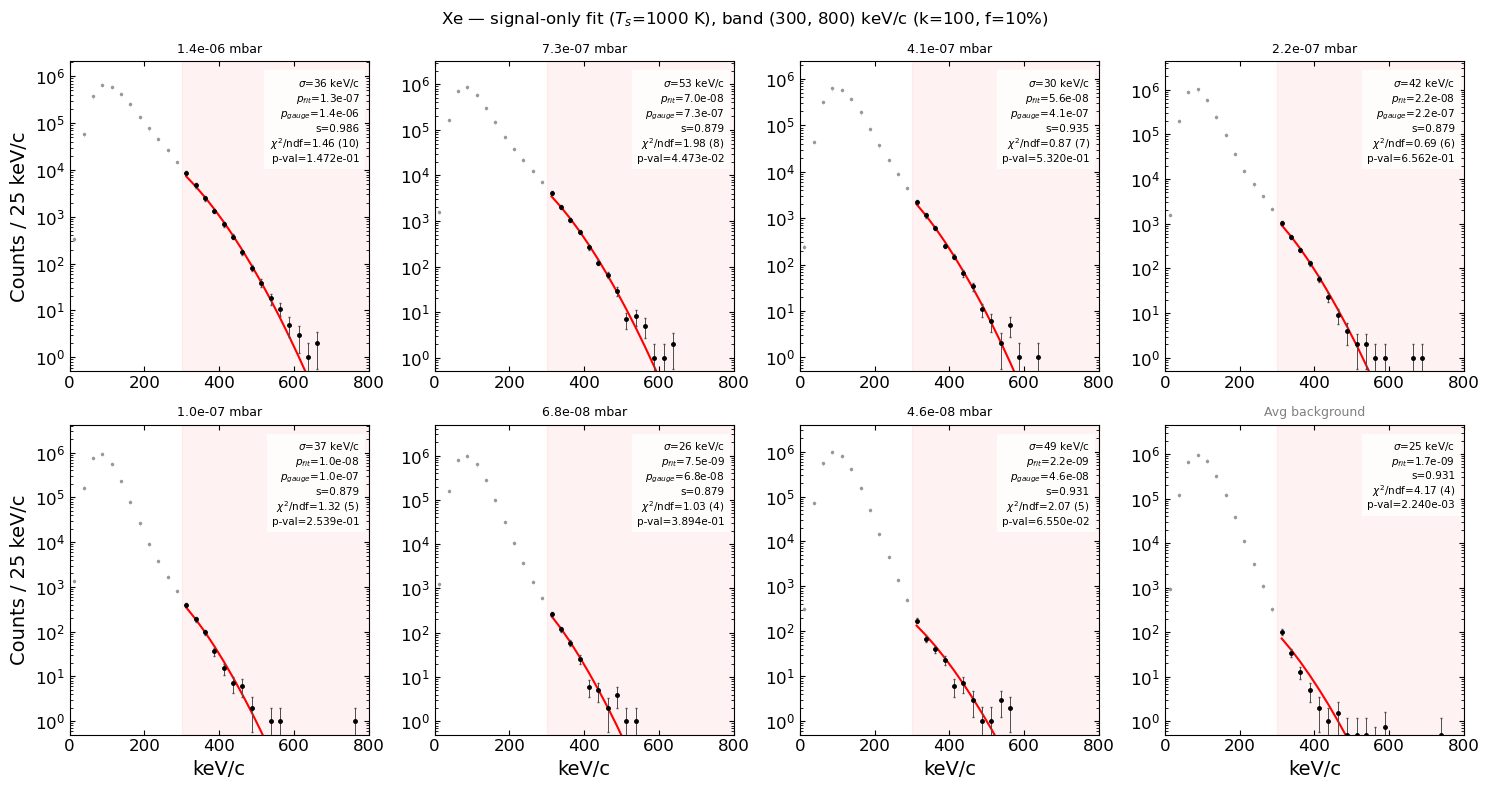

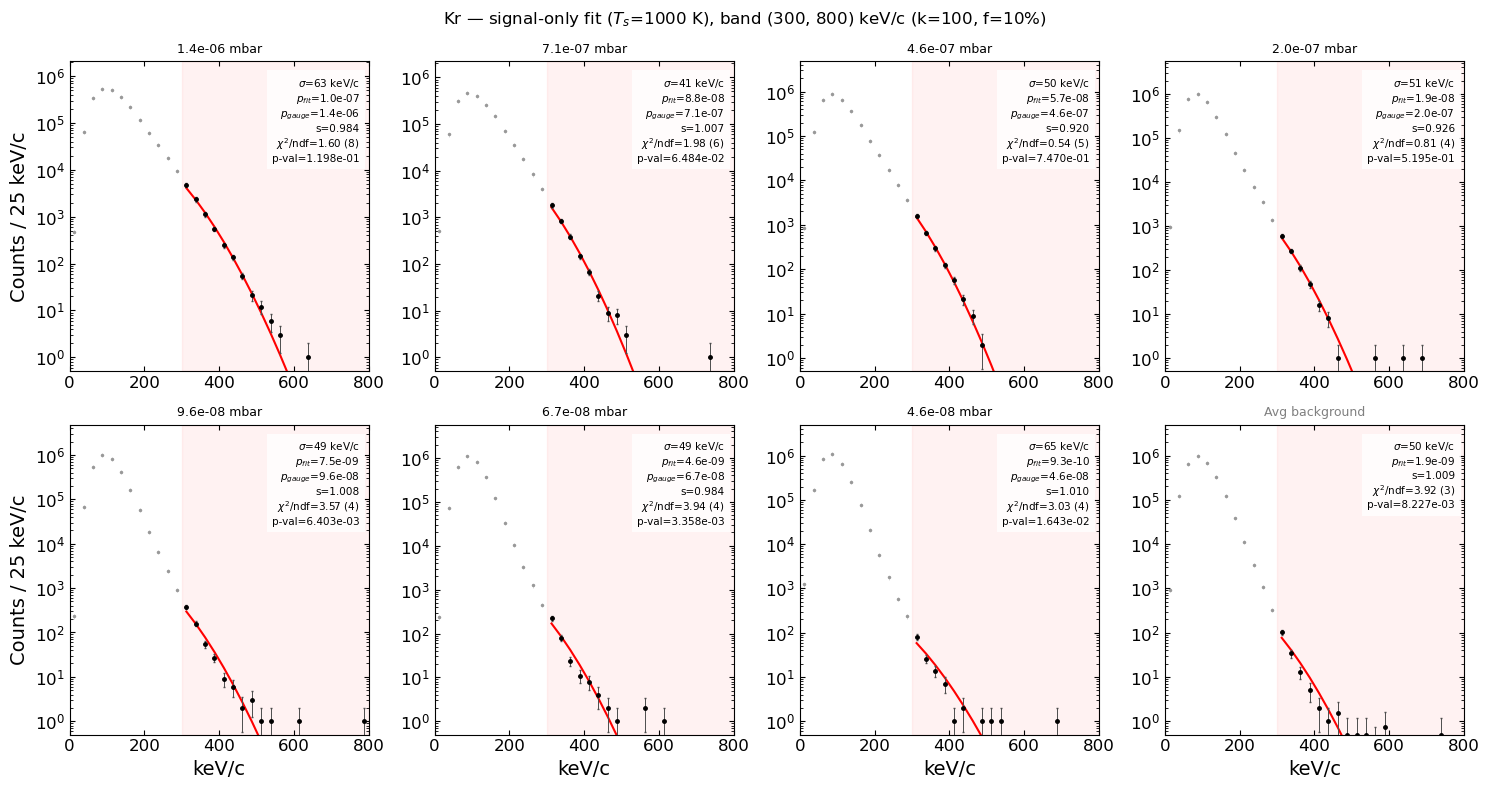

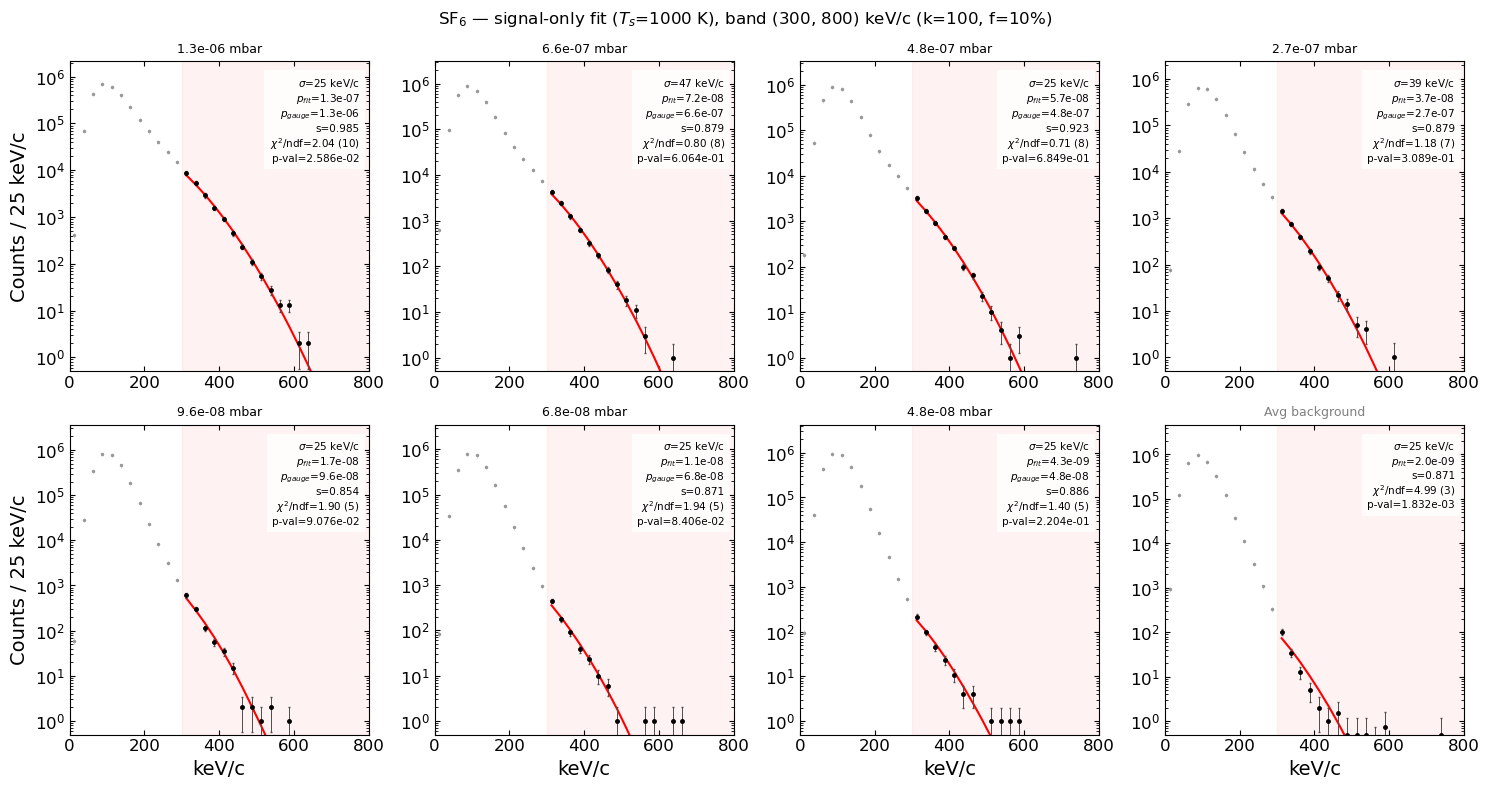

In [80]:
# Plot: Ts=1000 K signal-only fits, 2×4 grid per gas type (last panel = avg background)
dq = bc[1] - bc[0]

for gas in gas_masses:
    entries = hhs[gas]
    n = len(entries)
    ncols = 4
    nrows = 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 8))
    axes_flat = axes.flatten()

    drdqz_bc = drdqz_by_gas_hot[gas]

    n_total = n + 1

    for j in range(ncols * nrows):
        ax = axes_flat[j]
        if j >= n_total:
            ax.set_visible(False)
            continue

        is_bg = (j == n)
        if is_bg:
            r = results_sigonly_hot[('bg_as_' + gas, 0)]
        else:
            r = results_sigonly_hot[(gas, j)]

        h = r['hist'].astype(float)
        sigma = r['sigma']
        log10_p_fit = r['log10_p']
        amp_s = r['amp_scale']
        p_mbar = r['pressure_mbar']

        idx_fit = (bc > fit_band_sigonly[0]) & (bc < fit_band_sigonly[1])
        bc_fit = bc[idx_fit]

        err_full = np.sqrt(h + h**2 / k_negbin)
        err_fit = np.sqrt(h[idx_fit] + h[idx_fit]**2 / k_negbin)

        ax.errorbar(bc, h, yerr=err_full, fmt='none', ecolor='0.8', elinewidth=0.5, capsize=0)
        ax.plot(bc, h, 'o', ms=1.5, color='0.6')
        ax.errorbar(bc_fit, h[idx_fit], yerr=err_fit, fmt='o', ms=2.5, color='k',
                    ecolor='0.3', elinewidth=0.7, capsize=1, zorder=5)

        if amp_s != 1.0:
            drdqz_s = np.interp(bc / amp_s, bc, drdqz_bc) / amp_s
        else:
            drdqz_s = drdqz_bc
        _, drdqzn = calc_gas.smear_drdqz_gauss(bc, drdqz_s, sigma)
        p_scale = 10**(log10_p_fit - (-8))
        h_norm = np.sum(h) * glf.length_search_window * dq
        eff = glf.func_eff(bc, *glf.eff_coefs)
        h_gas = glf.eff_chi2 * eff * drdqzn * p_scale * h_norm

        ax.plot(bc_fit, h_gas[idx_fit], 'r-', lw=1.5, label='Signal')
        ax.axvspan(fit_band_sigonly[0], fit_band_sigonly[1], alpha=0.05, color='red')
        ax.set_yscale('log')
        ax.set_xlim(0, 800)
        ax.set_ylim(bottom=0.5)

        p_fit = 10**log10_p_fit
        ax.text(0.97, 0.95,
                f'$\\sigma$={sigma:.0f} keV/c\n'
                f'$p_{{fit}}$={p_fit:.1e}\n'
                + (f'$p_{{gauge}}$={p_mbar:.1e}\n' if not is_bg else '')
                + f's={amp_s:.3f}\n'
                f'$\\chi^2$/ndf={r["gof_chi2_ndf"]:.2f} ({r["gof_ndof"]})\n'
                f'p-val={r["gof_pval"]:.3e}',
                transform=ax.transAxes, va='top', ha='right', fontsize=7.5,
                bbox=dict(fc='white', alpha=0.8, ec='none'))

        if is_bg:
            ax.set_title('Avg background', fontsize=9, color='gray')
        else:
            ax.set_title(f'{p_mbar:.1e} mbar', fontsize=9)
        if j % ncols == 0:
            ax.set_ylabel('Counts / 25 keV/c')
        if j >= ncols:
            ax.set_xlabel('keV/c')

    fig.suptitle(f'{gas_labels[gas]} — signal-only fit ($T_s$={T_sensor_hot} K), '
                 f'band {fit_band_sigonly} keV/c (k={k_negbin:.0f}, f={frac_uncertainty:.0%})',
                 fontsize=12)
    fig.tight_layout()
    plt.show()

Background fit results (Ts=293 K vs 1000 K):
  xenon   : Ts=293  -> p_fit=7.49e-09, sigma=25.0, s=1.080
            Ts=1000 -> p_fit=1.72e-09, sigma=25.0, s=0.931
  krypton : Ts=293  -> p_fit=2.86e-09, sigma=74.7, s=1.030
            Ts=1000 -> p_fit=1.95e-09, sigma=49.8, s=1.009
  sf6     : Ts=293  -> p_fit=7.56e-09, sigma=25.0, s=1.025
            Ts=1000 -> p_fit=1.98e-09, sigma=25.0, s=0.871


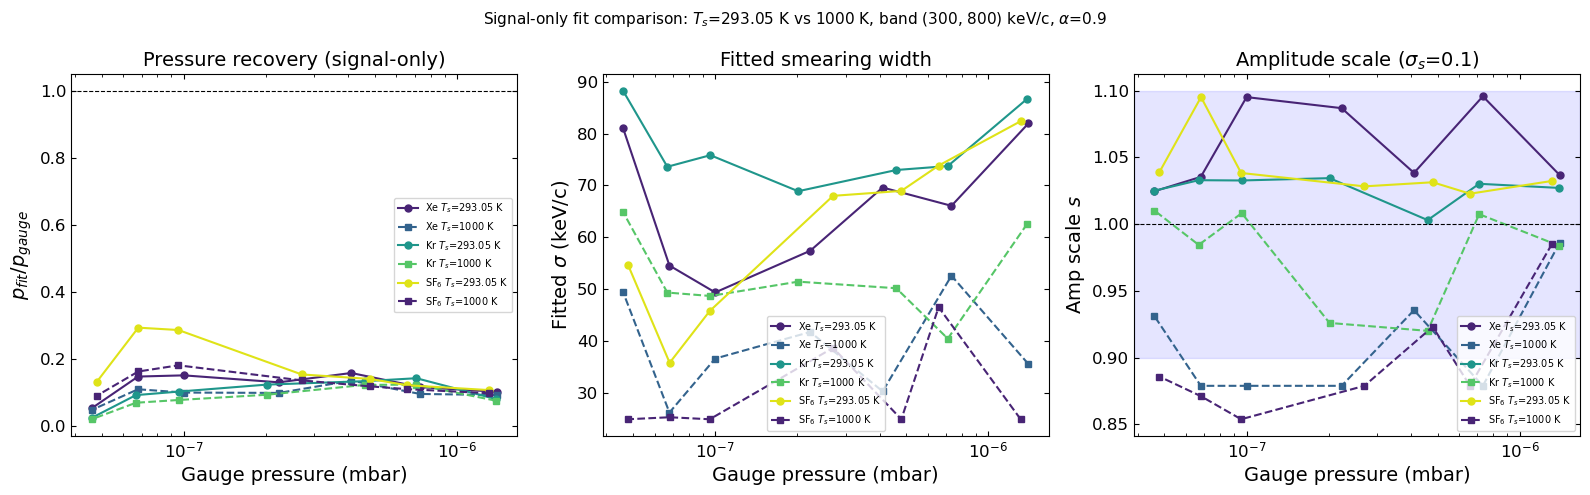

In [81]:
# Summary comparison: Ts=293 K vs Ts=1000 K
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for gas in gas_masses:
    n_datasets = len(hhs[gas])
    p_gauge = np.array([results_sigonly[(gas, i)]['pressure_mbar'] for i in range(n_datasets)])
    p_fit_cold = np.array([10**results_sigonly[(gas, i)]['log10_p'] for i in range(n_datasets)])
    p_fit_hot = np.array([10**results_sigonly_hot[(gas, i)]['log10_p'] for i in range(n_datasets)])

    axes[0].plot(p_gauge, p_fit_cold / p_gauge, 'o-', ms=5, label=f'{gas_labels[gas]} $T_s$={T_sensor} K')
    axes[0].plot(p_gauge, p_fit_hot / p_gauge, 's--', ms=5, label=f'{gas_labels[gas]} $T_s$={T_sensor_hot} K')

    sigmas_cold = np.array([results_sigonly[(gas, i)]['sigma'] for i in range(n_datasets)])
    sigmas_hot = np.array([results_sigonly_hot[(gas, i)]['sigma'] for i in range(n_datasets)])
    axes[1].plot(p_gauge, sigmas_cold, 'o-', ms=5, label=f'{gas_labels[gas]} $T_s$={T_sensor} K')
    axes[1].plot(p_gauge, sigmas_hot, 's--', ms=5, label=f'{gas_labels[gas]} $T_s$={T_sensor_hot} K')

    amps_cold = np.array([results_sigonly[(gas, i)]['amp_scale'] for i in range(n_datasets)])
    amps_hot = np.array([results_sigonly_hot[(gas, i)]['amp_scale'] for i in range(n_datasets)])
    axes[2].plot(p_gauge, amps_cold, 'o-', ms=5, label=f'{gas_labels[gas]} $T_s$={T_sensor} K')
    axes[2].plot(p_gauge, amps_hot, 's--', ms=5, label=f'{gas_labels[gas]} $T_s$={T_sensor_hot} K')

axes[0].axhline(1, color='k', ls='--', lw=0.8)
axes[0].set_xscale('log')
axes[0].set_xlabel('Gauge pressure (mbar)')
axes[0].set_ylabel('$p_{fit} / p_{gauge}$')
axes[0].legend(fontsize=7)
axes[0].set_title('Pressure recovery (signal-only)')

axes[1].set_xscale('log')
axes[1].set_xlabel('Gauge pressure (mbar)')
axes[1].set_ylabel('Fitted $\\sigma$ (keV/c)')
axes[1].legend(fontsize=7)
axes[1].set_title('Fitted smearing width')

axes[2].axhline(1, color='k', ls='--', lw=0.8)
axes[2].axhspan(1 - amp_scale_sigma, 1 + amp_scale_sigma, alpha=0.1, color='blue')
axes[2].set_xscale('log')
axes[2].set_xlabel('Gauge pressure (mbar)')
axes[2].set_ylabel('Amp scale $s$')
axes[2].legend(fontsize=7)
axes[2].set_title(f'Amplitude scale ($\\sigma_s$={amp_scale_sigma})')

# Print background fit comparison
print('Background fit results (Ts=293 K vs 1000 K):')
for gas in gas_masses:
    r293 = results_sigonly[('bg_as_' + gas, 0)]
    r1000 = results_sigonly_hot[('bg_as_' + gas, 0)]
    print(f'  {gas:8s}: Ts=293  -> p_fit={10**r293["log10_p"]:.2e}, sigma={r293["sigma"]:.1f}, s={r293["amp_scale"]:.3f}')
    print(f'  {"":<8s}  Ts=1000 -> p_fit={10**r1000["log10_p"]:.2e}, sigma={r1000["sigma"]:.1f}, s={r1000["amp_scale"]:.3f}')

fig.suptitle(f'Signal-only fit comparison: $T_s$={T_sensor} K vs {T_sensor_hot} K, '
             f'band {fit_band_sigonly} keV/c, $\\alpha$={alpha}', fontsize=11)
fig.tight_layout()
plt.show()

## Measured pressures vs gauge reading

In [82]:
# Profile likelihood errors on log10_p for all fits (both Ts)
importlib.reload(glf)

profile_errors = {}  # key: (gas, i, Ts) -> (err_lo, err_hi) in log10_p units

for Ts_label, results_dict, drdqz_dict, Ts_val in [
    ('293', results_sigonly, drdqz_by_gas, T_sensor),
    ('1000', results_sigonly_hot, drdqz_by_gas_hot, T_sensor_hot),
]:
    for gas in gas_masses:
        drdqz_bc = drdqz_dict[gas]
        for i in range(len(hhs[gas])):
            r = results_dict[(gas, i)]
            best_params = [r['sigma'], r['log10_p'], r['amp_scale']]
            h = r['hist']

            lo, hi, err_lo, err_hi, _, _ = glf.profile_log10_p_negbin(
                drdqz_bc, bc, h, glf.eff_coefs, glf.eff_chi2, fit_band_sigonly,
                k_negbin, glf.nll_offset, signal_only=True,
                amp_scale_sigma=amp_scale_sigma, best_params=best_params,
                n_scan=40, scan_half_width=1.0)

            profile_errors[(gas, i, Ts_label)] = (err_lo, err_hi)
            p_mbar = r['pressure_mbar']
            p_fit = 10**r['log10_p']
            p_lo = 10**lo
            p_hi = 10**hi
            print(f'  Ts={Ts_label} {gas:8s} {p_mbar:.1e}: '
                  f'p_fit={p_fit:.2e} [{p_lo:.2e}, {p_hi:.2e}]')

print(f'\nComputed {len(profile_errors)} profile intervals')

  Ts=293 xenon    1.4e-06: p_fit=1.43e-07 [1.47e-07, 1.55e-07]
  Ts=293 xenon    7.3e-07: p_fit=8.49e-08 [7.33e-08, 9.62e-08]
  Ts=293 xenon    4.1e-07: p_fit=6.49e-08 [7.51e-08, 7.84e-08]
  Ts=293 xenon    2.2e-07: p_fit=2.91e-08 [2.54e-08, 3.69e-08]
  Ts=293 xenon    1.0e-07: p_fit=1.51e-08 [1.13e-08, 1.93e-08]
  Ts=293 xenon    6.8e-08: p_fit=1.00e-08 [1.52e-08, 1.82e-08]
  Ts=293 xenon    4.6e-08: p_fit=2.43e-09 [1.89e-09, 3.23e-09]
  Ts=293 krypton  1.4e-06: p_fit=1.12e-07 [9.85e-08, 1.27e-07]
  Ts=293 krypton  7.1e-07: p_fit=1.01e-07 [8.52e-08, 1.35e-07]
  Ts=293 krypton  4.6e-07: p_fit=6.16e-08 [5.02e-08, 7.77e-08]
  Ts=293 krypton  2.0e-07: p_fit=2.49e-08 [1.92e-08, 2.88e-08]
  Ts=293 krypton  9.6e-08: p_fit=9.87e-09 [9.05e-09, 2.30e-08]
  Ts=293 krypton  6.7e-08: p_fit=6.16e-09 [5.63e-09, 2.23e-08]
  Ts=293 krypton  4.6e-08: p_fit=1.12e-09 [7.56e-10, 1.78e-09]
  Ts=293 sf6      1.3e-06: p_fit=1.41e-07 [1.24e-07, 1.56e-07]
  Ts=293 sf6      6.6e-07: p_fit=8.00e-08 [7.04e-08, 9.

Average background gauge pressure: 3.40e-08 mbar


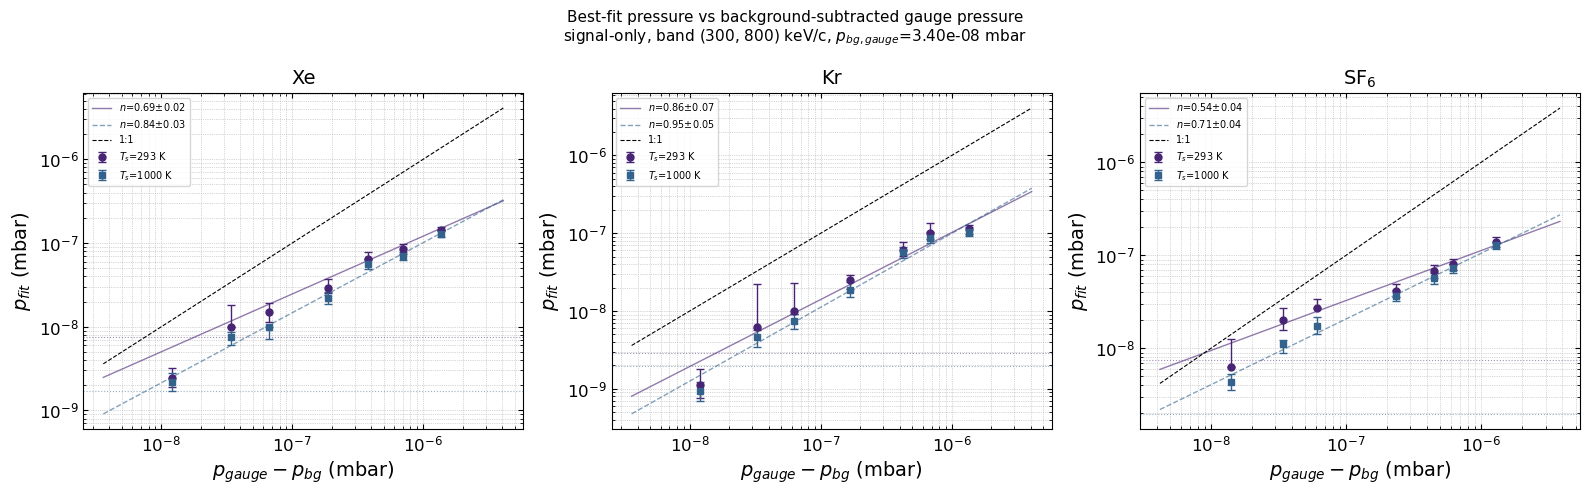

In [83]:
# p_fit vs background-subtracted gauge pressure, with profile likelihood errors and power-law fit
from scipy.optimize import curve_fit

p_bg_gauge_avg = np.mean([hhs['background'][i][3] for i in range(len(hhs['background']))])
print(f'Average background gauge pressure: {p_bg_gauge_avg:.2e} mbar')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (gas, label) in zip(axes, [('xenon', 'Xe'), ('krypton', 'Kr'), ('sf6', 'SF$_6$')]):
    n_datasets = len(hhs[gas])
    p_gauge_raw = np.array([results_sigonly[(gas, i)]['pressure_mbar'] for i in range(n_datasets)])
    p_gauge_corr = p_gauge_raw - p_bg_gauge_avg

    for Ts_label, results_dict, marker, ls, color in [
        ('293', results_sigonly, 'o', '-', 'C0'),
        ('1000', results_sigonly_hot, 's', '--', 'C1'),
    ]:
        p_fit = np.array([10**results_dict[(gas, i)]['log10_p'] for i in range(n_datasets)])
        log10_p_fit = np.array([results_dict[(gas, i)]['log10_p'] for i in range(n_datasets)])

        # Asymmetric errors in linear space from profile likelihood
        err_lo_log = np.array([profile_errors[(gas, i, Ts_label)][0] for i in range(n_datasets)])
        err_hi_log = np.array([profile_errors[(gas, i, Ts_label)][1] for i in range(n_datasets)])

        # Replace nan errors with 0 so errorbar doesn't fail
        err_lo_log_safe = np.where(np.isfinite(err_lo_log), err_lo_log, 0)
        err_hi_log_safe = np.where(np.isfinite(err_hi_log), err_hi_log, 0)

        p_err_lo = p_fit - 10**(log10_p_fit - err_lo_log_safe)
        p_err_hi = 10**(log10_p_fit + err_hi_log_safe) - p_fit

        # Clamp to non-negative (safety)
        p_err_lo = np.maximum(p_err_lo, 0)
        p_err_hi = np.maximum(p_err_hi, 0)

        ax.errorbar(p_gauge_corr, p_fit, yerr=[p_err_lo, p_err_hi],
                    fmt=marker, ms=5, color=color, ecolor=color, elinewidth=1, capsize=3,
                    label=f'$T_s$={Ts_label} K')

        # Power-law fit in log-log: log10(p_fit) = logA + n * log10(p_gauge_corr)
        mask = p_gauge_corr > 0
        if np.sum(mask) >= 2:
            # Symmetric error in log space for weighting
            sigma_log = 0.5 * (err_lo_log_safe[mask] + err_hi_log_safe[mask])
            sigma_log = np.where(sigma_log > 0, sigma_log, 0.1)  # floor for points without profile error

            popt, pcov = curve_fit(
                lambda x, logA, n: logA + n * x,
                np.log10(p_gauge_corr[mask]), log10_p_fit[mask],
                sigma=sigma_log, absolute_sigma=True,
                p0=[0, 1])
            logA_fit, n_fit = popt
            logA_err, n_err = np.sqrt(np.diag(pcov))

            xx = np.logspace(np.log10(p_gauge_corr[mask].min() * 0.3),
                             np.log10(p_gauge_corr[mask].max() * 3), 100)
            yy = 10**(logA_fit + n_fit * np.log10(xx))
            ax.plot(xx, yy, ls, color=color, lw=1, alpha=0.6,
                    label=f'$n$={n_fit:.2f}$\\pm${n_err:.2f}')

    # Background fit level
    p_bg_fit_cold = 10**results_sigonly[('bg_as_' + gas, 0)]['log10_p']
    p_bg_fit_hot = 10**results_sigonly_hot[('bg_as_' + gas, 0)]['log10_p']
    ax.axhline(p_bg_fit_cold, color='C0', ls=':', lw=0.8, alpha=0.5)
    ax.axhline(p_bg_fit_hot, color='C1', ls=':', lw=0.8, alpha=0.5)

    # 1:1 line
    pmin, pmax = p_gauge_corr[p_gauge_corr > 0].min() * 0.3, p_gauge_corr.max() * 3
    ax.plot([pmin, pmax], [pmin, pmax], 'k--', lw=0.8, label='1:1')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('$p_{gauge} - p_{bg}$ (mbar)')
    ax.set_ylabel('$p_{fit}$ (mbar)')
    ax.set_title(label)
    ax.legend(fontsize=7)
    ax.grid(which='both', ls=':', lw=0.5)

fig.suptitle(f'Best-fit pressure vs background-subtracted gauge pressure\n'
             f'signal-only, band {fit_band_sigonly} keV/c, $p_{{bg,gauge}}$={p_bg_gauge_avg:.2e} mbar',
             fontsize=11)
fig.tight_layout()
plt.show()

## 2D likelihood scan: Xe 1e-7 mbar (signal-only, 300–800 keV/c)

In [87]:
from scipy.optimize import minimize

# Find the Xe 1e-7 mbar dataset from hhs
scan_fit_band = (300, 800)
scan_gas = 'xenon'
target_p = 1e-7

# hhs is sorted high→low pressure; find closest to 1e-7
scan_idx = min(range(len(hhs[scan_gas])),
               key=lambda i: abs(hhs[scan_gas][i][3] - target_p))
_, scan_hist, _, scan_p_mbar = hhs[scan_gas][scan_idx]
print(f'Selected: index {scan_idx}, p_gauge = {scan_p_mbar:.2e} mbar, total counts = {scan_hist.sum():.0f}')

# 2D scan grid — profile over amp_scale at each point
log10_p_list = np.linspace(-9, -5, 120)
sigma_list = np.linspace(20, 120, 100)

drdqz_bc_scan = drdqz_by_gas[scan_gas]

nll_scan = np.empty((len(log10_p_list), len(sigma_list)))
amp_scale_scan = np.empty_like(nll_scan)

for i, log10_p in enumerate(log10_p_list):
    for j, sigma in enumerate(sigma_list):
        # Profile over amp_scale with Gaussian constraint
        def obj_s(s):
            return glf.nll_sigma_pressure_negbin(
                sigma, log10_p, drdqz_bc_scan, bc, scan_hist,
                glf.eff_coefs, glf.eff_chi2, scan_fit_band,
                k_negbin, 0, signal_only=True,
                amp_scale=s[0], amp_scale_sigma=amp_scale_sigma)
        res_s = minimize(obj_s, [1.0], method='Nelder-Mead',
                         bounds=[(0.7, 1.3)],
                         options={'maxiter': 1000, 'fatol': 0.001})
        nll_scan[i, j] = res_s.fun
        amp_scale_scan[i, j] = res_s.x[0]

# Best-fit from scan
idx_r, idx_c = np.unravel_index(np.argmin(nll_scan), nll_scan.shape)
log10_p_bf = log10_p_list[idx_r]
sigma_bf = sigma_list[idx_c]
amp_scale_bf = amp_scale_scan[idx_r, idx_c]
print(f'Best fit: sigma = {sigma_bf:.1f} keV/c, log10(p) = {log10_p_bf:.3f} -> p = {10**log10_p_bf:.2e} mbar, s = {amp_scale_bf:.3f}')

Selected: index 4, p_gauge = 1.00e-07 mbar, total counts = 2749856
Best fit: sigma = 34.1 keV/c, log10(p) = -7.790 -> p = 1.62e-08 mbar, s = 1.160


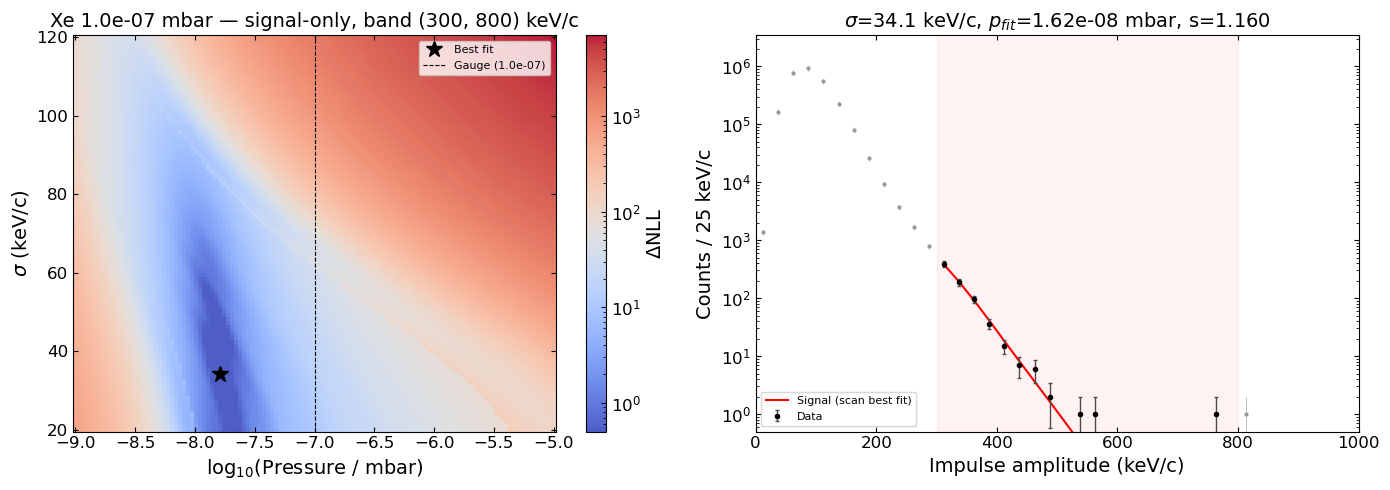

In [88]:
from matplotlib.colors import LogNorm

dnll = nll_scan - np.min(nll_scan)
X, Y = np.meshgrid(log10_p_list, sigma_list)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: 2D heatmap
ax = axes[0]
pcm = ax.pcolormesh(X, Y, dnll.T, norm=LogNorm(vmin=0.5, vmax=dnll.max()),
                    cmap='coolwarm', edgecolor='none', alpha=0.9)
ax.plot(log10_p_bf, sigma_bf, 'k*', ms=12, label=f'Best fit')
ax.axvline(np.log10(scan_p_mbar), color='k', ls='--', lw=0.8, label=f'Gauge ({scan_p_mbar:.1e})')
fig.colorbar(pcm, ax=ax, label='$\\Delta$NLL')
ax.set_xlabel('log$_{10}$(Pressure / mbar)')
ax.set_ylabel('$\\sigma$ (keV/c)')
ax.set_title(f'Xe {scan_p_mbar:.1e} mbar — signal-only, band {scan_fit_band} keV/c')
ax.legend(fontsize=8)

# Right: best-fit overlay on data
ax = axes[1]
dq = bc[1] - bc[0]
idx_fit = (bc > scan_fit_band[0]) & (bc < scan_fit_band[1])
bc_fit = bc[idx_fit]

h = scan_hist.astype(float)
err_full = np.sqrt(h + h**2 / k_negbin)

ax.errorbar(bc, h, yerr=err_full, fmt='none', ecolor='0.75', elinewidth=0.7, capsize=0)
ax.plot(bc, h, 'o', ms=2, color='0.6')
ax.errorbar(bc_fit, h[idx_fit], yerr=np.sqrt(h[idx_fit] + h[idx_fit]**2 / k_negbin),
            fmt='o', ms=3, color='k', ecolor='0.3', elinewidth=1, capsize=1.5, label='Data', zorder=5)

# Apply amp_scale to theory for the best-fit overlay
if amp_scale_bf != 1.0:
    drdqz_s = np.interp(bc / amp_scale_bf, bc, drdqz_bc_scan) / amp_scale_bf
else:
    drdqz_s = drdqz_bc_scan
_, drdqzn_bf = calc_gas.smear_drdqz_gauss(bc, drdqz_s, sigma_bf)
p_scale = 10**(log10_p_bf - (-8))
h_norm = np.sum(h) * glf.length_search_window * dq
eff = glf.func_eff(bc, *glf.eff_coefs)
h_gas = glf.eff_chi2 * eff * drdqzn_bf * p_scale * h_norm

ax.plot(bc_fit, h_gas[idx_fit], 'r-', lw=1.5, label='Signal (scan best fit)')
ax.axvspan(scan_fit_band[0], scan_fit_band[1], alpha=0.05, color='red')

ax.set_yscale('log')
ax.set_xlim(0, 1000)
ax.set_ylim(bottom=0.5)
ax.set_xlabel('Impulse amplitude (keV/c)')
ax.set_ylabel('Counts / 25 keV/c')
ax.set_title(f'$\\sigma$={sigma_bf:.1f} keV/c, $p_{{fit}}$={10**log10_p_bf:.2e} mbar, s={amp_scale_bf:.3f}')
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

## 2D likelihood scan: SF6 1e-7 mbar (signal-only, 300–800 keV/c)

In [89]:
# Find the SF6 9.6e-8 mbar dataset from hhs
scan_fit_band = (300, 800)
scan_gas = 'sf6'
target_p = 9.6e-8

scan_idx = min(range(len(hhs[scan_gas])),
               key=lambda i: abs(hhs[scan_gas][i][3] - target_p))
_, scan_hist, _, scan_p_mbar = hhs[scan_gas][scan_idx]
print(f'Selected: index {scan_idx}, p_gauge = {scan_p_mbar:.2e} mbar, total counts = {scan_hist.sum():.0f}')

# 2D scan grid — profile over amp_scale at each point
log10_p_list = np.linspace(-9, -5, 120)
sigma_list = np.linspace(20, 120, 100)

drdqz_bc_scan = drdqz_by_gas[scan_gas]

nll_scan = np.empty((len(log10_p_list), len(sigma_list)))
amp_scale_scan = np.empty_like(nll_scan)

for i, log10_p in enumerate(log10_p_list):
    for j, sigma in enumerate(sigma_list):
        def obj_s(s):
            return glf.nll_sigma_pressure_negbin(
                sigma, log10_p, drdqz_bc_scan, bc, scan_hist,
                glf.eff_coefs, glf.eff_chi2, scan_fit_band,
                k_negbin, 0, signal_only=True,
                amp_scale=s[0], amp_scale_sigma=amp_scale_sigma)
        res_s = minimize(obj_s, [1.0], method='Nelder-Mead',
                         bounds=[(0.7, 1.3)],
                         options={'maxiter': 1000, 'fatol': 0.001})
        nll_scan[i, j] = res_s.fun
        amp_scale_scan[i, j] = res_s.x[0]

# Best-fit from scan
idx_r, idx_c = np.unravel_index(np.argmin(nll_scan), nll_scan.shape)
log10_p_bf = log10_p_list[idx_r]
sigma_bf = sigma_list[idx_c]
amp_scale_bf = amp_scale_scan[idx_r, idx_c]
print(f'Best fit: sigma = {sigma_bf:.1f} keV/c, log10(p) = {log10_p_bf:.3f} -> p = {10**log10_p_bf:.2e} mbar, s = {amp_scale_bf:.3f}')

Selected: index 4, p_gauge = 9.55e-08 mbar, total counts = 2689882
Best fit: sigma = 28.1 keV/c, log10(p) = -7.454 -> p = 3.52e-08 mbar, s = 1.088


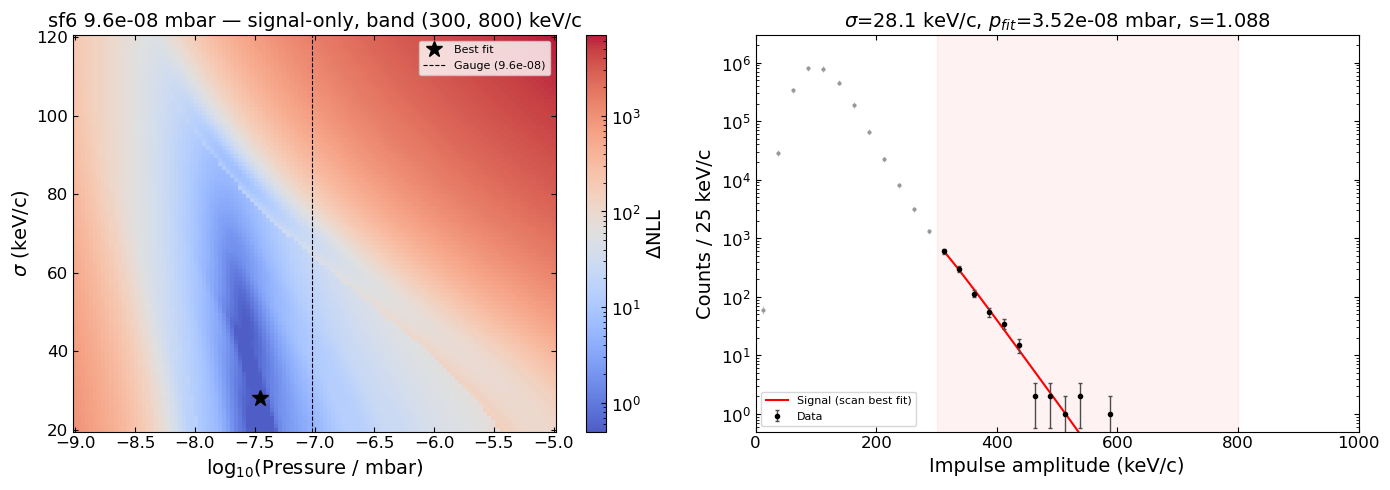

In [90]:
from matplotlib.colors import LogNorm

dnll = nll_scan - np.min(nll_scan)
X, Y = np.meshgrid(log10_p_list, sigma_list)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: 2D heatmap
ax = axes[0]
pcm = ax.pcolormesh(X, Y, dnll.T, norm=LogNorm(vmin=0.5, vmax=dnll.max()),
                    cmap='coolwarm', edgecolor='none', alpha=0.9)
ax.plot(log10_p_bf, sigma_bf, 'k*', ms=12, label=f'Best fit')
ax.axvline(np.log10(scan_p_mbar), color='k', ls='--', lw=0.8, label=f'Gauge ({scan_p_mbar:.1e})')
fig.colorbar(pcm, ax=ax, label='$\\Delta$NLL')
ax.set_xlabel('log$_{10}$(Pressure / mbar)')
ax.set_ylabel('$\\sigma$ (keV/c)')
ax.set_title(f'{scan_gas} {scan_p_mbar:.1e} mbar — signal-only, band {scan_fit_band} keV/c')
ax.legend(fontsize=8)

# Right: best-fit overlay on data
ax = axes[1]
dq = bc[1] - bc[0]
idx_fit = (bc > scan_fit_band[0]) & (bc < scan_fit_band[1])
bc_fit = bc[idx_fit]

h = scan_hist.astype(float)
err_full = np.sqrt(h + h**2 / k_negbin)

ax.errorbar(bc, h, yerr=err_full, fmt='none', ecolor='0.75', elinewidth=0.7, capsize=0)
ax.plot(bc, h, 'o', ms=2, color='0.6')
ax.errorbar(bc_fit, h[idx_fit], yerr=np.sqrt(h[idx_fit] + h[idx_fit]**2 / k_negbin),
            fmt='o', ms=3, color='k', ecolor='0.3', elinewidth=1, capsize=1.5, label='Data', zorder=5)

# Apply amp_scale to theory for the best-fit overlay
if amp_scale_bf != 1.0:
    drdqz_s = np.interp(bc / amp_scale_bf, bc, drdqz_bc_scan) / amp_scale_bf
else:
    drdqz_s = drdqz_bc_scan
_, drdqzn_bf = calc_gas.smear_drdqz_gauss(bc, drdqz_s, sigma_bf)
p_scale = 10**(log10_p_bf - (-8))
h_norm = np.sum(h) * glf.length_search_window * dq
eff = glf.func_eff(bc, *glf.eff_coefs)
h_gas = glf.eff_chi2 * eff * drdqzn_bf * p_scale * h_norm

ax.plot(bc_fit, h_gas[idx_fit], 'r-', lw=1.5, label='Signal (scan best fit)')
ax.axvspan(scan_fit_band[0], scan_fit_band[1], alpha=0.05, color='red')

ax.set_yscale('log')
ax.set_xlim(0, 1000)
ax.set_ylim(bottom=0.5)
ax.set_xlabel('Impulse amplitude (keV/c)')
ax.set_ylabel('Counts / 25 keV/c')
ax.set_title(f'$\\sigma$={sigma_bf:.1f} keV/c, $p_{{fit}}$={10**log10_p_bf:.2e} mbar, s={amp_scale_bf:.3f}')
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()